# Cada peso deja una huella

**Decisión:** ¿Qué pagos maximizan exposición revisada y fuerza de evidencia?

Notebook ejecutado sobre la muestra versionada del repositorio.

## 1. Contrato y calidad

Se comprueba la trazabilidad de la fuente, el tamaño de la muestra y las métricas finitas.

In [1]:
from pathlib import Path
from IPython.display import Image, display
from portfolio_analytics.common import project_root, read_json
root = project_root()
project = root / 'projects/05-spend-anomalies'
source = read_json(project / 'data/source.json')
display({'rows': source['rows'], 'source': source['url'], 'retrieved_at': source['retrieved_at']})

{'rows': 25000,
 'source': 'https://nyc-databook-spending.s3.amazonaws.com/fiscal_year=2024/chunk_0001.parquet',
 'retrieved_at': '2026-07-30T05:10:15+00:00'}

## 2. Ejecución reproducible

La siguiente celda vuelve a correr la lógica compartida por el script y las pruebas.

In [2]:
from portfolio_analytics.spend_anomalies import analyze
metrics = analyze(project / 'data/sample.csv', project / 'outputs')
display(metrics)

{'payments': 25000,
 'agencies': 80,
 'payees': 4021,
 'total_exposure_usd': 16160658456.77,
 'review_queue_rows': 250,
 'review_queue_exposure_usd': 6742374389.81,
 'injected_anomaly_recall': 0.92,
 'top_evidence_payee': 'STATE OF NEW YORK',
 'top_evidence_score': 99.98,
 'missing_contract_flags': 18,
 'duplicate_like_flags': 311}

## 3. Resultado visual

La figura se genera desde los mismos datos y queda versionada para revisión rápida.

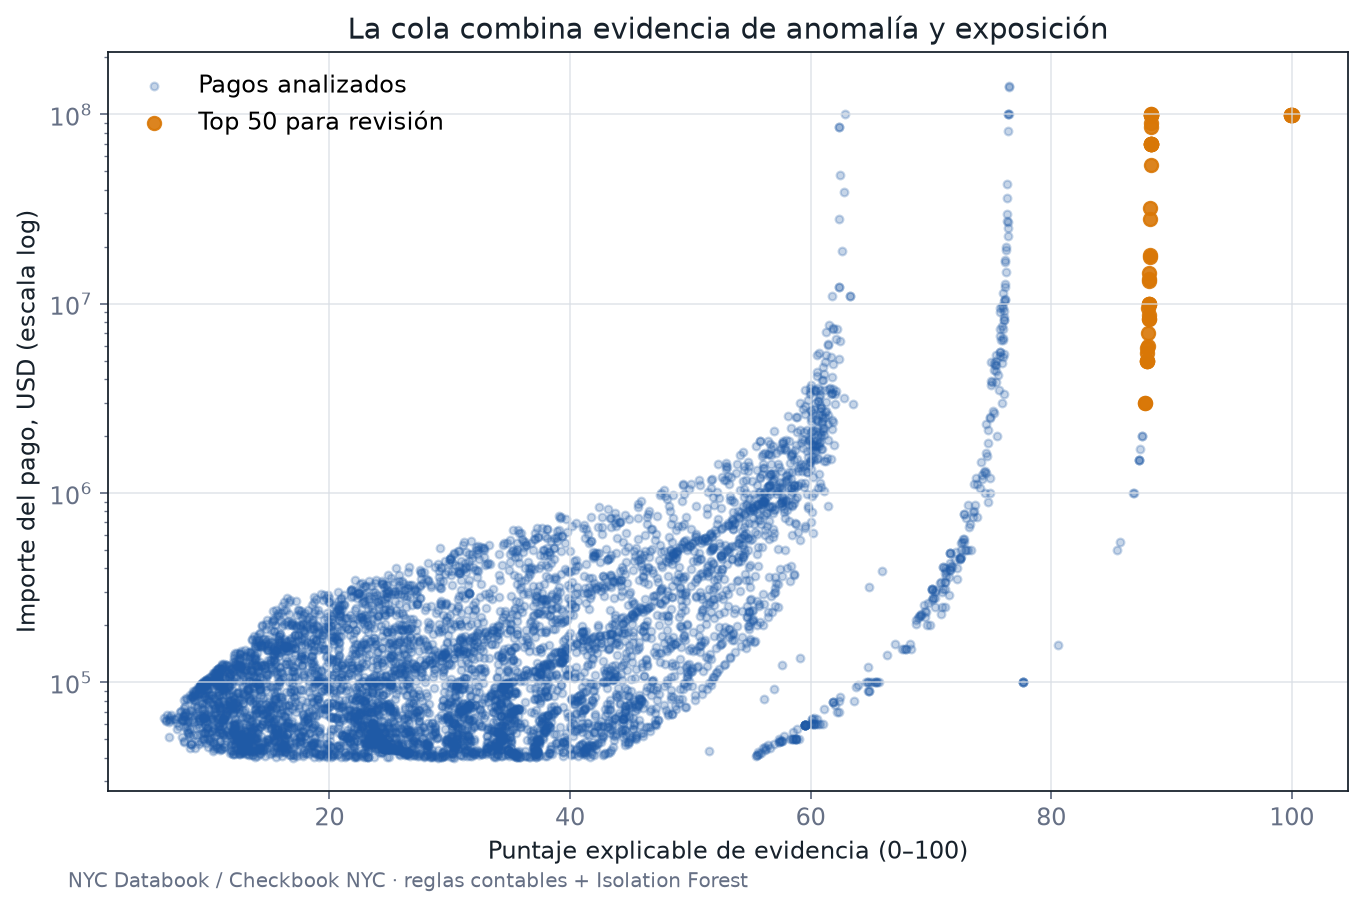

In [3]:
display(Image(filename=str(project / 'outputs/figure.png'), width=900))

## 4. Conclusión y límite

Una anomalía abre una revisión documental; nunca confirma fraude por sí sola.